In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import os

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
print(esc_fresnel.path)

from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.utils as utils
import esc_fresnel.dm as dm
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics


/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-05-07 08:53:50,490	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


/home/kianmilani/Projects/esc-fresnel/esc_fresnel


In [2]:
poppy.xp

<module 'cupy' from '/home/kianmilani/miniconda3/envs/km311cpu/lib/python3.11/site-packages/cupy/__init__.py'>

In [ ]:
wfe_dir = 'V20250325-cropped'
wfe_dir = 'V20250326-cropped'

dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat.fits')

wfe_keys = [
    'm1',
    'm2',
    'm3', 
    'm4',
    'oap1',
    'fm1',
    'oap2',
    'oap3',
    'fsm',
    'fm2',
    'oap4',
    'oap5',
    'input_lp',
    'input_qwp',
    'oap6',
    'oap7',
    'oap9',
    'collimator',
    'filter',
    'output_qwp',
    'output_lp',
    'oap10',
]

wfes = {}
for optic in wfe_keys:
    wfe = poppy.FITSOpticalElement(
        opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_opd.fits'), 
        opdunits='nanometers',
        transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_amp.fits'),
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

# dm_map = poppy.FITSOpticalElement(
#     opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat.fits'), 
#     opdunits='meters',
#     name=f'dm_wfe',
#     pixelscale='SCALE',
#     planetype=poppy.poppy_core.PlaneType.intermediate,
# )
# dm_map.opd *= 2

dm_map = poppy.FITSOpticalElement(
    opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat_interpped.fits'), 
    opdunits='meters',
    name=f'dm_wfe',
    planetype=poppy.poppy_core.PlaneType.intermediate,
)

wfes.update({'DM':dm_map})

0


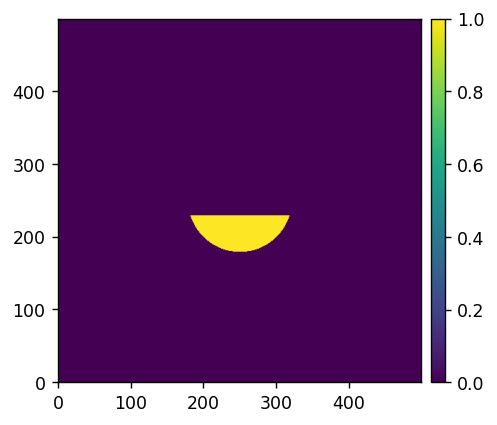

1


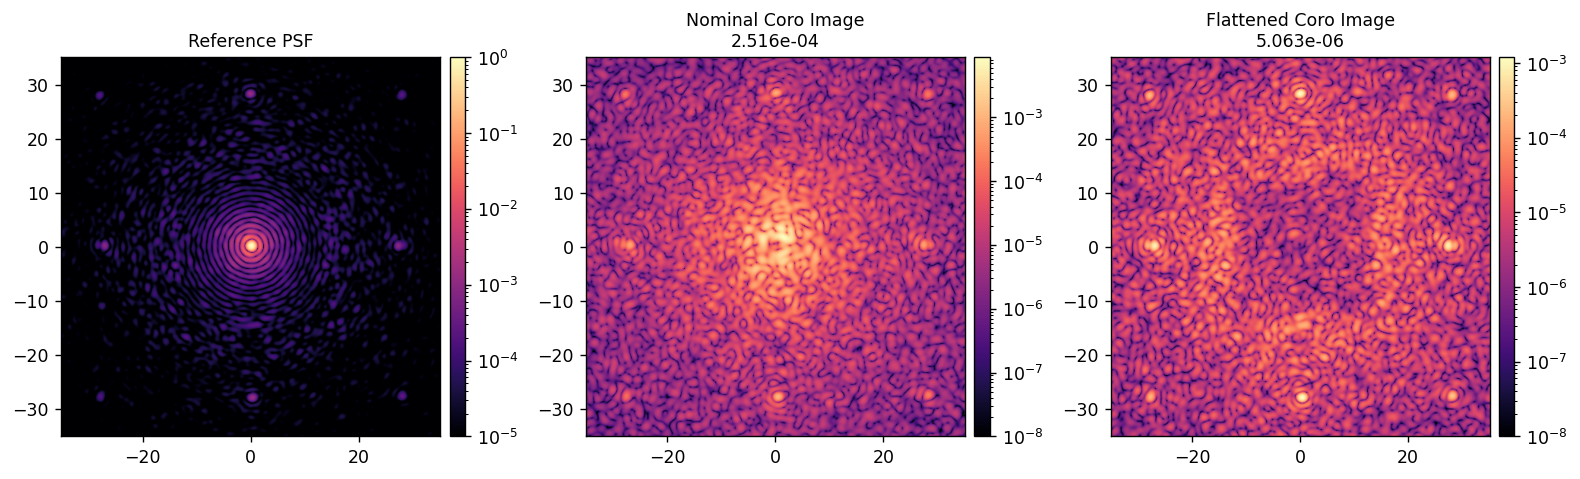

In [5]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 500

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
M.zero_dm()
coro_im_0 = M.snap()

M.reset_dm()
coro_im_flat = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow([coro_mask])

contrast_0 = utils.mean(coro_im_0, coro_mask)
contrast_flat = utils.mean(coro_im_flat, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_0, coro_im_flat],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Nominal Coro Image\n{contrast_0:.3e}',
            f'Flattened Coro Image\n{contrast_flat:.3e}',],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-8)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

In [6]:
%timeit -n 10 M.snap()

330 ms ± 740 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Time parallelized models

In [3]:
ACTORS = []
for i in range(N_waves):
    params = {
        'wavelength':waves[i],
        # 'npix':1000,
        # 'oversample':4.096,
    }
    ACTORS.append(ray_esc.options(num_cpus=4, num_gpus=1).remote(**params))


2025-03-19 09:35:32,290	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


(pid=1364552) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
(pid=1364552)   cupy._util.experimental('cupyx.jit.rawkernel')
(single pid=1364552) Oversampling > 2x suggested for reliable results in Fresnel propagation.
(pid=1364548) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future. [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=1364548)   cupy._util.experimental('cupyx.jit.rawkernel') [repeated 4x across cluster]
(single pid=1364542) Oversampling > 2x suggested for reliable results in Fresnel propagation.


1


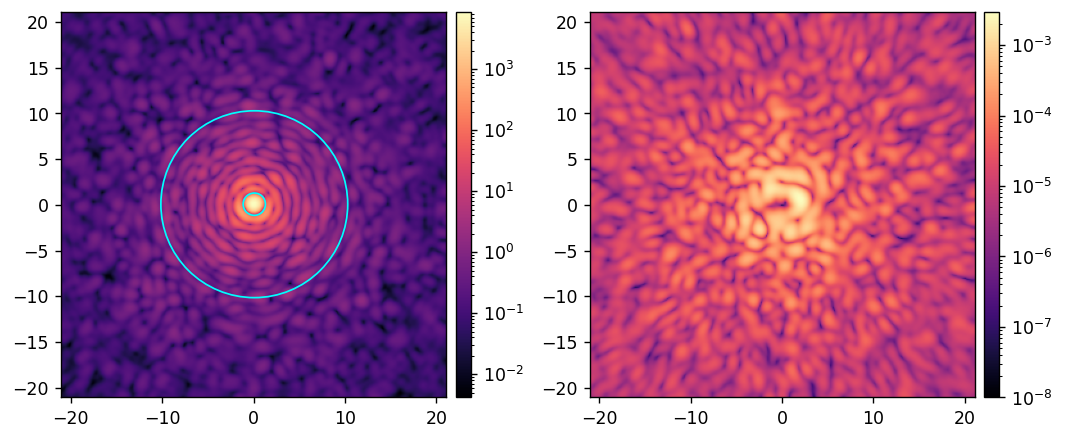

In [12]:
reload(esc)
M = esc.parallel(ACTORS)
M.setattr('wfes', wfes)

M.setattr('Imax_ref', 1)
M.setattr('use_vortex', False)
ref_psf = M.snap()
# M.Imax_ref = xp.max(ref_psf)
M.setattr('Imax_ref', xp.max(ref_psf))

M.setattr('use_vortex', True)
ref_coro_im = M.snap()

psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
imshow(
    [ref_psf/M.Imax_ref, ref_coro_im], 
    cmaps=['magma']*2,
    norms=[LogNorm(), LogNorm(1e-8)],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    all_patches=[ [Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')] ],
)

In [9]:
M.npix, M.oversample

(1000, 4.096)

In [11]:
M.setattr('use_vortex', True)

%timeit -n 10 M.snap()

394 ms ± 3.74 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


1


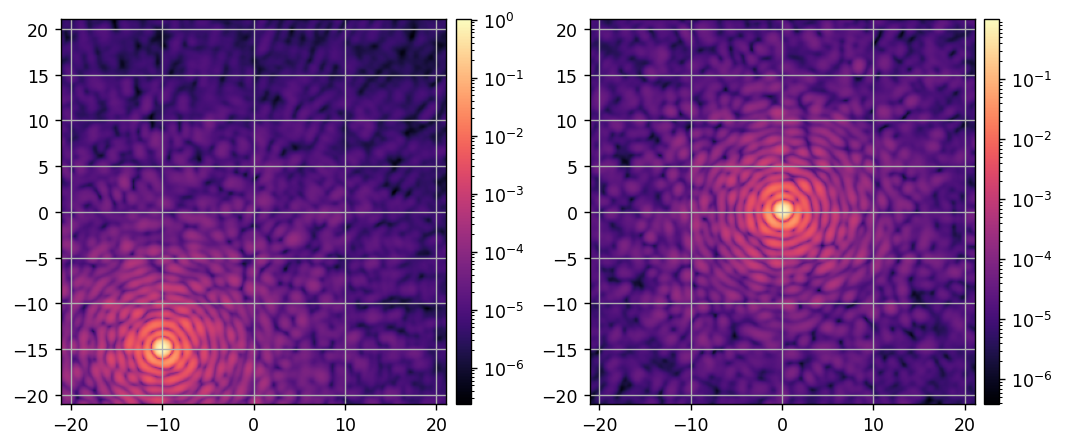

In [19]:
source_offset = np.array([-10, -15])
M.setattr('use_vortex', False)

M.setattr('source_offset', source_offset)
M.set_m4( [0, 0] )
M.set_fsm( [0, 0] )
psf1 = M.snap()

M.setattr('source_offset', source_offset)
M.set_m4( -source_offset )
# M.set_fsm( -source_offset )
psf2 = M.snap()

imshow(
    [psf1, psf2], 
    cmaps=['magma']*2,
    norms=[LogNorm(), LogNorm()],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    grids=[1, 1],
)